<a href="https://colab.research.google.com/github/sampoornanath28032007-svg/test/blob/main/MDE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
focal_length = 800.0
real_world_size = 1.7


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
def pixel_size_from_distance(distance):
    return (focal_length * real_world_size) / distance
print(pixel_size_from_distance(5))
print(pixel_size_from_distance(50))


272.0
27.2


In [ ]:
import numpy as np
distances = np.random.uniform(2,100, 500)
print(distances[:5])

[25.89772568 53.63150149 73.30888421 59.84301884  7.24445963]


In [ ]:
pixel_sizes = (focal_length * real_world_size) / distances
print(pixel_sizes[:5])

[ 52.51426387  25.35823093  18.55163961  22.72612623 187.72966774]


In [ ]:
noise = np.random.normal(0 , 5 , 500)
pixel_sizes_noisy = pixel_sizes + noise
print(pixel_sizes[:5])
print(pixel_sizes_noisy[:5])

[ 52.51426387  25.35823093  18.55163961  22.72612623 187.72966774]
[ 51.24095287  18.35846351  15.79411188   9.51708862 179.03493997]


In [ ]:
x = pixel_sizes_noisy.reshape(-1 ,1)
y = distances.reshape(-1,1)
print(x.shape)
print(y.shape)

(500, 1)
(500, 1)


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test , y_train, y_test = train_test_split(x,y, test_size = 0.2 , random_state = 42)
print(x_train.shape)
print(x_test.shape)


(400, 1)
(100, 1)


In [ ]:
from sklearn.neural_network import MLPRegressor

model = MLPRegressor(hidden_layer_sizes=(16, 16), max_iter=2000, random_state=42)
model.fit(x_train, y_train.ravel())

MLPRegressor(hidden_layer_sizes=(16, 16), max_iter=2000, random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error

predictions = model.predict(x_test)
mae = mean_absolute_error(y_test, predictions)
print(mae)

for true_val, pred_val in zip(y_test[:5], predictions[:5]):
    print(f"true: {true_val[0]:.1f}, predicted: {pred_val:.1f}")


17.34533295455895
true: 31.4, predicted: 49.8
true: 33.5, predicted: 49.9
true: 57.7, predicted: 55.3
true: 30.5, predicted: 46.7
true: 56.5, predicted: 52.6


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = MLPRegressor(hidden_layer_sizes=(16, 16), max_iter=2000, random_state=42)
model.fit(x_train_scaled, y_train.ravel())

predictions = model.predict(x_test_scaled)
mae = mean_absolute_error(y_test, predictions)
print(mae)

for true_val, pred_val in zip(y_test[:5], predictions[:5]):
    print(f"true: {true_val[0]:.1f}, predicted: {pred_val:.1f}")


7.232212151541928
true: 31.4, predicted: 31.8
true: 33.5, predicted: 32.0
true: 57.7, predicted: 73.8
true: 30.5, predicted: 24.2
true: 56.5, predicted: 50.6


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
model = MLPRegressor(hidden_layer_sizes=(16, 16), max_iter=5000, random_state=42)
model.fit(x_train_scaled, y_train.ravel())

predictions = model.predict(x_test_scaled)
mae = mean_absolute_error(y_test, predictions)
print("MAE:", mae)


MAE: 7.173570702334611


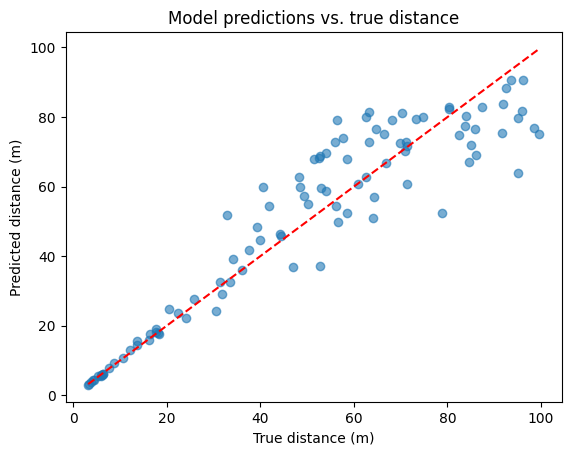

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect-prediction line
plt.xlabel("True distance (m)")
plt.ylabel("Predicted distance (m)")
plt.title("Model predictions vs. true distance")
plt.show()

In [ ]:
import joblib
joblib.dump(model, 'distance_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Saved.")


Saved.
